In [1]:
import tensorflow as tf

import os
from pathlib import Path
import datetime
import numpy as np
import random


from IPython.display import display, clear_output
from tqdm.notebook import tqdm, trange

from fid import get_frechet_inception_distance
import pandas as pd

from normalize import images_from_normalized
from data_generator import PreprocessedDataGenerator
from plot import plot_results
from model import get_generator_model_no_previous, get_discriminator_model
from loss import l1_loss, euclidean_distance, GeneratorLoss, DiscriminatorLoss, pairwise_loss
from splits import TRAIN_PATHS, TEST_PATHS

2023-06-28 18:59:40.331481: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-06-28 18:59:40.382955: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
COHERENCE_LOSS = None
MAIN_LOSS = l1_loss
LANDMARKS_LOSS = None
LANDMARKS_COHERENCE_LOSS = None

# Dimensions
r = 128
IMG_WIDTH = r
IMG_HEIGHT = r
N_CHANNELS = 3

N_LANDMARKS = 68

BATCH_SIZE = 100
STEPS = 100000
STEPS = STEPS // BATCH_SIZE
SAVING_EACH_STEPS = 50
DISPLAY_EACH_STEPS = 20
N_TESTING_FRAMES = 42000

LAMBDA1 = 1000
LAMBDA2 = 200
LAMBDA3 = 100
LAMBDA4 = 10

VIDEOS_FOLDER = f'mug{r}'
BASE_PATH = Path('../')
DATA_PATH = BASE_PATH / 'data'
APP_PATH = BASE_PATH / 'app'

## Load the dataset

In [3]:
# videos_path = list((DATA_PATH / VIDEOS_FOLDER).glob('**/*.npy'))

In [4]:
# DATASET_SIZE = len(videos_path)
# train_size = int(0.7 * DATASET_SIZE)
# # val_size = int(0.15 * DATASET_SIZE)
# test_size = int(0.3 * DATASET_SIZE)

# # generate training, validation and test sets
# train_paths = videos_path[:train_size]
# # val_sequences = sequences[train_size:train_size+val_size]
# # test_sequences = sequences[train_size+val_size:]
# test_paths = videos_path[train_size:]

# tf.print(len(train_paths))
# tf.print(len(test_paths))

# # shuffle list of paths
# random.shuffle(train_paths)
# random.shuffle(test_paths)

In [5]:
train_paths = TRAIN_PATHS
test_paths = TEST_PATHS

2023-06-28 18:59:46.882659: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13809 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:b3:00.0, compute capability: 8.6


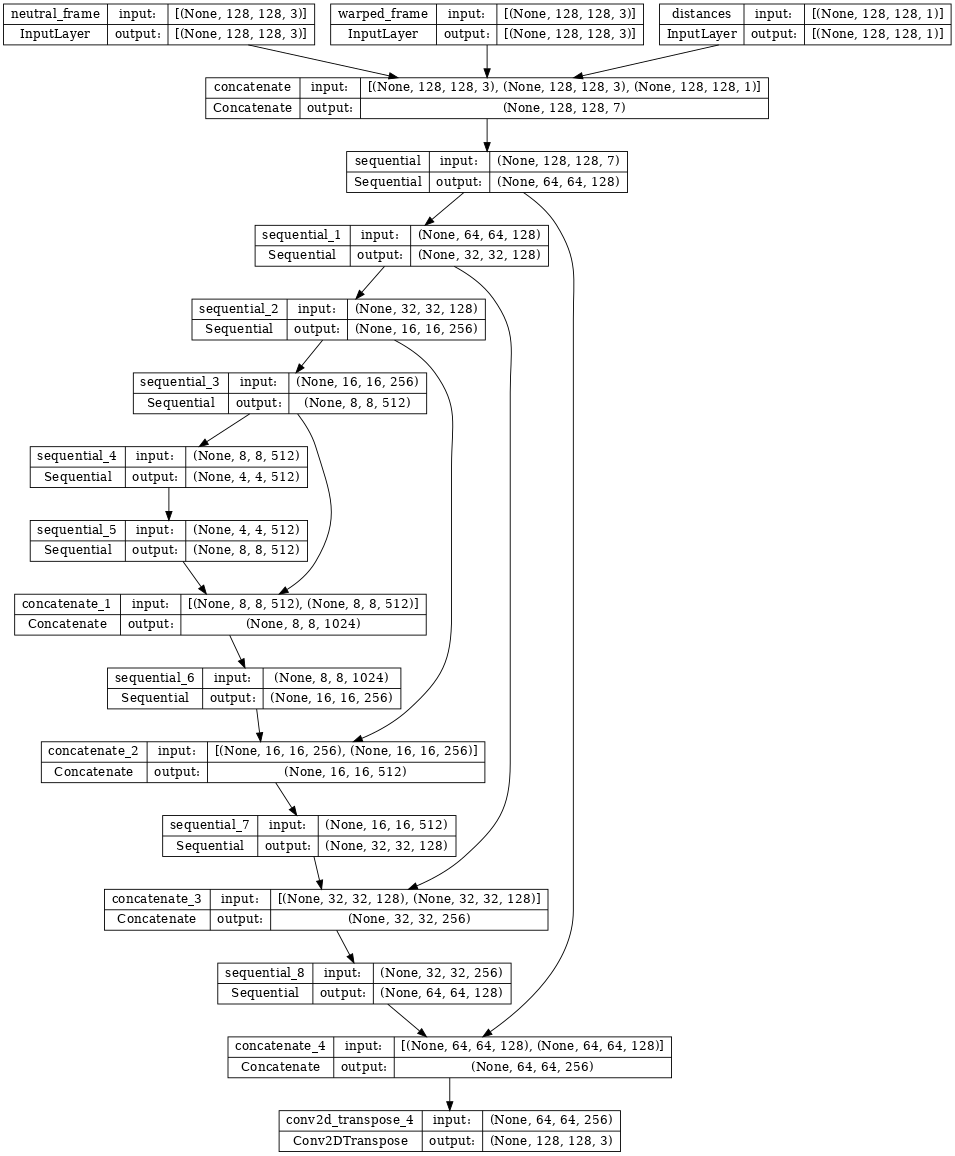

In [6]:
generator = get_generator_model_no_previous(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64, to_file='output/generator.png')

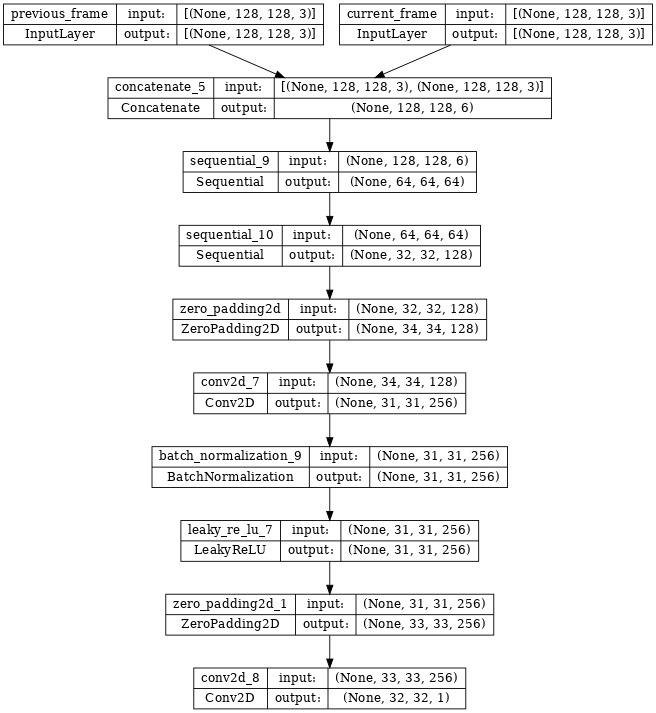

In [7]:
discriminator = get_discriminator_model(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64, to_file='output/discriminator.png')

In [8]:
generator_loss = GeneratorLoss(MAIN_LOSS,
                lambda_main_loss=LAMBDA1,
                coherence_loss_function=COHERENCE_LOSS,
                lambda_coherence_loss=LAMBDA2,
                landmarks_loss_function=None,
                lambda_landmarks_loss=0,
                landmarks_coherence_loss_function=LANDMARKS_COHERENCE_LOSS,
                lambda_landmarks_coherence_loss=LAMBDA4)

In [9]:
discriminator_loss = DiscriminatorLoss()

In [10]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [11]:
id_string = f"no_previous_b{BATCH_SIZE}_r{r}_"
if MAIN_LOSS:
    id_string += f"f1_{MAIN_LOSS.__name__}_{LAMBDA1}"
if COHERENCE_LOSS:
    id_string += f"_f2_{COHERENCE_LOSS.__name__}_{LAMBDA2}"
if LANDMARKS_LOSS:
    id_string += f"_f3_{LANDMARKS_LOSS.__name__}_{LAMBDA3}"
if LANDMARKS_COHERENCE_LOSS:
    id_string += f"_f4_{LANDMARKS_COHERENCE_LOSS.__name__}_{LAMBDA4}"
id_string

'no_previous_b100_r128_f1_l1_loss_1000'

In [12]:
BASE_DIR = APP_PATH / 'output' / id_string
checkpoint_dir = str(BASE_DIR / 'training_checkpoints')
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

## Training


In [13]:
log_dir=BASE_DIR / "logs/"
log_file = log_dir / "fit" / datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = tf.summary.create_file_writer(str(log_file))

In [14]:
def fit(train_dataset_generator, test_dataset_generator, steps):
  pbar = tqdm(range(steps), total=steps)
  for step in pbar:
    with tf.profiler.experimental.Trace('train', step_num=step, _r=1):

      if (step) % DISPLAY_EACH_STEPS == 0:
        clear_output(wait=True)
        display(pbar.container)
        previously_generated, generated_frames, samples_target = test_dataset_generator.generate_next_batch()
        plot_results(samples_target, previously_generated, generated_frames)

      with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_total_loss, disc_loss, gen_gan_loss, gen_target_predicted, gen_coherence_loss, gen_landmarks_loss, gen_landmarks_coherence_loss = train_dataset_generator.next_loss()
        generator_gradients = gen_tape.gradient(gen_total_loss,
                                                generator.trainable_variables)
        discriminator_gradients = disc_tape.gradient(disc_loss,
                                                    discriminator.trainable_variables)

        generator_optimizer.apply_gradients(zip(generator_gradients,
                                                generator.trainable_variables))
        discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                                    discriminator.trainable_variables))
        with summary_writer.as_default():
          tf.summary.scalar(f'gen_total_loss', gen_total_loss, step=step)
          tf.summary.scalar(f'gen_gan_loss', gen_gan_loss, step=step)
          tf.summary.scalar(f'disc_loss', disc_loss, step=step)
          if generator_loss.main_loss_function:
            tf.summary.scalar(f'gen_target_predicted', gen_target_predicted, step=step)
          if generator_loss.coherence_loss_function:
            tf.summary.scalar(f'gen_coherence', gen_coherence_loss, step=step)
          if generator_loss.landmarks_loss_function:
            tf.summary.scalar(f'gen_landmarks_loss', gen_landmarks_loss, step=step)
          if generator_loss.landmarks_coherence_loss_function:
            tf.summary.scalar(f'gen_landmarks_coherence_loss', gen_landmarks_coherence_loss, step=step)
      
      if (step + 1) % SAVING_EACH_STEPS == 0:
          checkpoint.save(file_prefix=checkpoint_prefix)

In [15]:
tf.profiler.experimental.start(str(log_dir))

2023-06-28 18:59:49.154699: I tensorflow/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2023-06-28 18:59:49.154780: I tensorflow/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2023-06-28 18:59:49.154907: I tensorflow/compiler/xla/backends/profiler/gpu/cupti_tracer.cc:1679] Profiler found 1 GPUs


In [16]:
train_generator = PreprocessedDataGenerator(train_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=True)
test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [17]:
# c = 0
# for p in TRAIN_PATHS:
#     a = np.load(p)
#     c += len(a)
#     if c > 5400:
#         print(p)
#         break

In [18]:
p = "../data/mug128/063/sadness/take001nsg/video.npy"
np.load(p).shape

(70, 128, 128, 3)

  0%|          | 0/1000 [00:00<?, ?it/s]

FIRST
video_path ../data/mug128/042/anger/take001/video.npy
batch_frames (94, 128, 128, 3)
batch_first_frames (94, 128, 128, 3)
len(batch_frames) 94
begin_batch 1
end_batch 101

LOOP
video_path ../data/mug128/065/fear/take001nsg/video.npy
batch_frames (100, 128, 128, 3)
batch_first_frames (94, 128, 128, 3)
self.n_first_frames(n_added_frames) (6, 128, 128, 3)
n_added_frames 6
begin_batch 1
end_batch 7



2023-06-28 18:59:59.028426: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600


Input Sequence


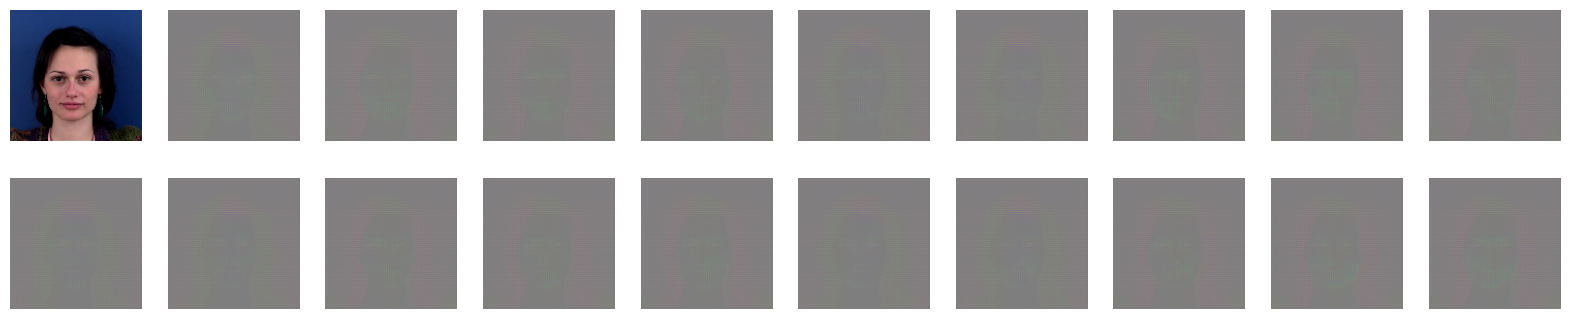

Ground Truth


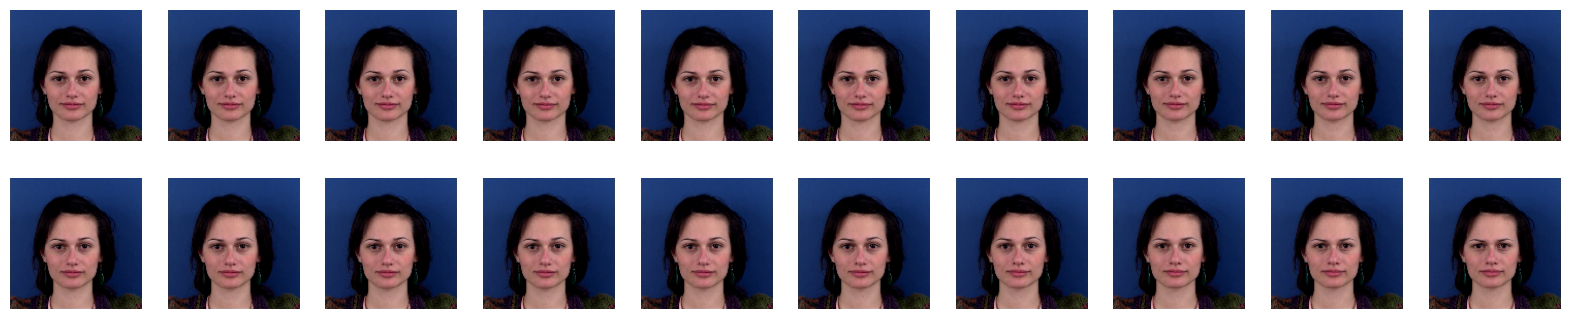

Predicted Sequence


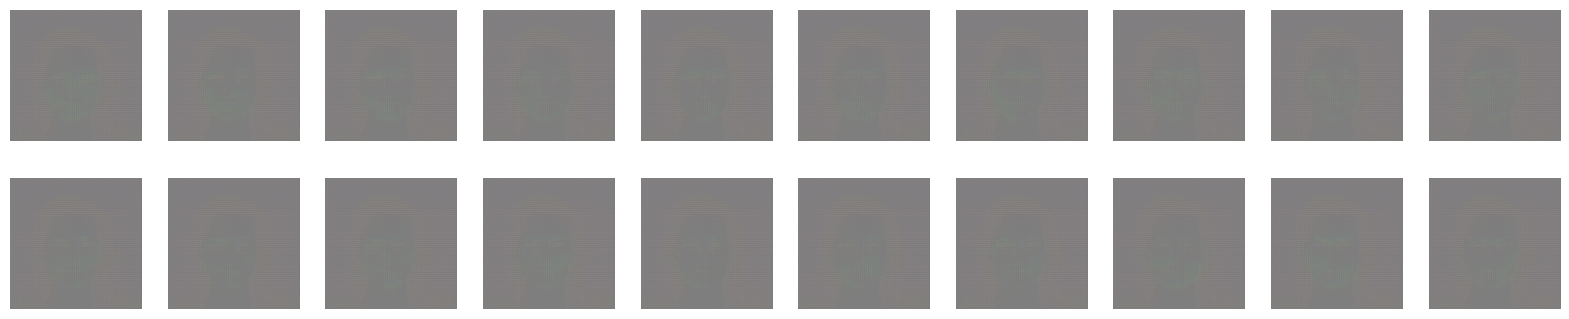

FIRST
video_path ../data/mug128/071/disgust/take002/video.npy
batch_frames (79, 128, 128, 3)
batch_first_frames (79, 128, 128, 3)
len(batch_frames) 79
begin_batch 1
end_batch 101

LOOP
video_path ../data/mug128/033/disgust/take002/video.npy
batch_frames (100, 128, 128, 3)
batch_first_frames (79, 128, 128, 3)
self.n_first_frames(n_added_frames) (21, 128, 128, 3)
n_added_frames 21
begin_batch 1
end_batch 22



2023-06-28 19:00:18.228304: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0xd78c58d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-06-28 19:00:18.228349: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): NVIDIA RTX A4000, Compute Capability 8.6
2023-06-28 19:00:18.233364: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2023-06-28 19:00:18.441858: I ./tensorflow/compiler/jit/device_compiler.h:180] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


FIRST
video_path ../data/mug128/033/disgust/take002/video.npy
batch_frames (64, 128, 128, 3)
batch_first_frames (64, 128, 128, 3)
len(batch_frames) 64
begin_batch 22
end_batch 122

LOOP
video_path ../data/mug128/010/anger/take002/video.npy
batch_frames (100, 128, 128, 3)
batch_first_frames (64, 128, 128, 3)
self.n_first_frames(n_added_frames) (36, 128, 128, 3)
n_added_frames 36
begin_batch 1
end_batch 37

FIRST
video_path ../data/mug128/010/anger/take002/video.npy
batch_frames (12, 128, 128, 3)
batch_first_frames (12, 128, 128, 3)
len(batch_frames) 12
begin_batch 37
end_batch 137

LOOP
video_path ../data/mug128/049/session0/mixed/take000/video.npy
batch_frames (89, 128, 128, 3)
batch_first_frames (12, 128, 128, 3)
self.n_first_frames(n_added_frames) (77, 128, 128, 3)
n_added_frames 77
begin_batch 1
end_batch 89

LOOP
video_path ../data/mug128/072/disgust/take001nsg/video.npy
batch_frames (100, 128, 128, 3)
batch_first_frames (89, 128, 128, 3)
self.n_first_frames(n_added_frames) (11, 12

In [19]:
fit(train_generator, test_generator, steps=STEPS) # TODO: plot input to make sure its correct

## Restore the latest checkpoint and test the network

In [ ]:
!ls {checkpoint_dir}

In [ ]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

## Generate some images using the test set

In [ ]:
test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
for i in range(0,10):
  previously_generated, generated_frames, samples_target = test_generator.generate_next_batch()
  plot_results(samples_target, previously_generated, generated_frames)

In [ ]:
# adapted from https://gist.github.com/lukoshkin/6205455d5b931dcdbd923323003058f0 
# and https://github.com/valerystrizh/mocogan_modified/blob/0860daaa6564b563b5acc1d88f19bac051c1d1c6/src/metrics.py
def acd(frames):
    N = np.multiply.reduce(frames.shape[1:-1])
    res = np.mean(
            np.linalg.norm(
              np.diff(
                np.einsum('ijkl->il', frames), 
              axis=0) / N, 
            axis=1)
          ) 

    return res

def compare_acd(target_sequence, generated_output):
    return np.abs(acd(target_sequence) - acd(generated_output))

In [ ]:
test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)

In [ ]:
# evaluating the results with SSIM
def evaluate_metrics(normalized_target_sequence, normalized_generated_output, batch_size):
    target_sequence = images_from_normalized(normalized_target_sequence)
    generated_output = images_from_normalized(normalized_generated_output)
    #cast to float32
    normalized_target_sequence = tf.cast(normalized_target_sequence, tf.float32)
    normalized_generated_output = tf.cast(normalized_generated_output, tf.float32)
    #compute ssim
    ssim_scores = tf.image.ssim(target_sequence, generated_output, max_val=255)
    #compute psnr
    psnr_scores = tf.image.psnr(target_sequence, generated_output, max_val=255)
    #compute mse
    mse_scores = tf.keras.losses.MSE(normalized_target_sequence, normalized_generated_output)
    #compute l1
    l1_scores = tf.keras.losses.MAE(normalized_target_sequence, normalized_generated_output)
    # compute fid
    fid_scores = get_frechet_inception_distance(target_sequence, generated_output, batch_size=batch_size, num_inception_images=batch_size) # TODO: pre frame
    # compute fvd
    # fvd_scores = calculate_fvd(target_sequence, generated_output)
    # compute acd
    acd_scores = compare_acd(target_sequence, generated_output) # TODO: per video
    return  {
        "SSIM": tf.reduce_mean(ssim_scores).numpy(),
        "PSNR": tf.reduce_mean(psnr_scores).numpy(),
        "MSE": tf.reduce_mean(mse_scores).numpy(),
        "L1": tf.reduce_mean(l1_scores).numpy(),
        # "FVD": fvd_scores
        "FID": fid_scores.numpy(),
        "ACD": acd_scores
    }


scores = []
with tqdm(total=N_TESTING_FRAMES) as pbar:
    for _, generated_frames, current_frames in test_generator.generate_next_batch():
        s = evaluate_metrics(target_frames, predicted_frames, batch_size=BATCH_SIZE)
        scores.append(s)
        pbar.update(BATCH_SIZE)
  

In [ ]:
len(scores)
df = pd.DataFrame(scores)
df.to_csv(f"{log_dir}/metrics.csv")
print(df)

In [ ]:
print(df.mean())